In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
import ScraperFC as sfc

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [25]:
df = pd.read_csv("xg_model.csv")
df.head()

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,...,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner
0,80.8,51.6,False,SecondHalf,True,Center,True,True,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,79.3,24.2,False,SecondHalf,True,Center,True,True,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80.0,59.5,False,SecondHalf,True,Center,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,89.8,55.6,False,SecondHalf,True,Center,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84.9,56.2,False,SecondHalf,True,Center,NaN,True,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
print(df.shape)
df.describe()

(8118, 25)


,x,y
count,8118.000000,8118.000000
mean,85.538987,50.036056
std,8.770946,12.207702
min,0.800000,3.100000
25%,80.500000,41.300000
50%,87.200000,50.000000
75%,91.200000,58.700000
max,99.600000,99.600000


In [27]:
df.columns

Index(['x', 'y', 'is_goal', 'period', 'Assisted', 'Zone', 'IndividualPlay',
       'RegularPlay', 'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch',
       'Head', 'BigChance', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'DirectFreekick',
       'OwnGoal', 'OtherBodyPart', 'DirectCorner'],
      dtype='str')

In [28]:
# remove own goals
df = df[df['OwnGoal'] != True]
df.drop('OwnGoal', axis=1, inplace=True)

In [29]:
# remove NAs by converting them to false
df = df.fillna(False)

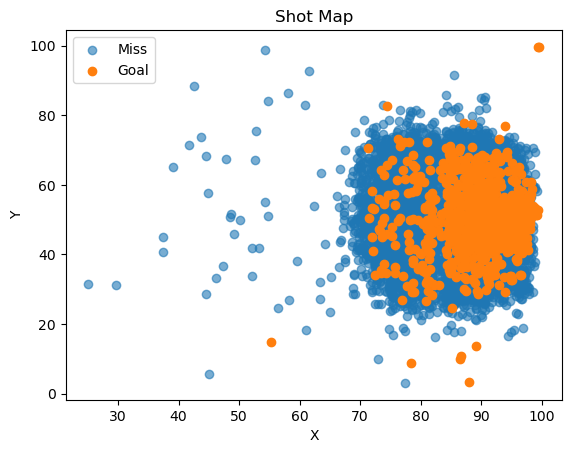

In [30]:
plt.figure()

# Misses
misses = df[df["is_goal"] == False]
plt.scatter(misses["x"], misses["y"], label="Miss", alpha=0.6)

# Goals
goals = df[df["is_goal"] == True]
plt.scatter(goals["x"], goals["y"], label="Goal")

plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Shot Map")

plt.show()

<Axes: xlabel='x', ylabel='y'>

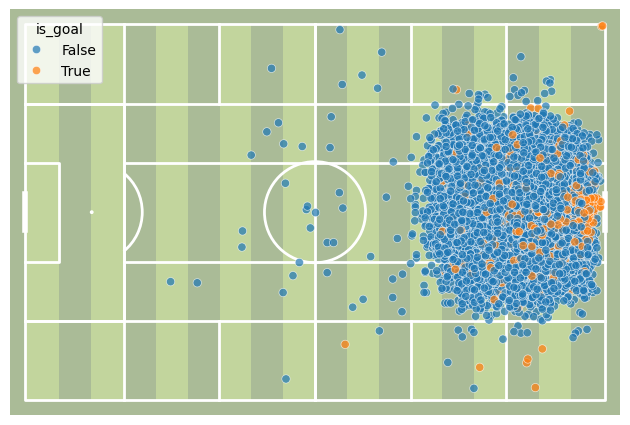

In [31]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=df, hue='is_goal', alpha=0.7, ax=ax)

In [32]:
df.dtypes

x                  float64
y                  float64
is_goal               bool
period                 str
Assisted            object
Zone                   str
IndividualPlay      object
RegularPlay         object
LeftFoot            object
RightFoot           object
FromCorner          object
FirstTouch          object
Head                object
BigChance           object
SetPiece            object
Volley              object
FastBreak           object
ThrowinSetPiece     object
Penalty             object
OneOnOne            object
KeyPass             object
DirectFreekick      object
OtherBodyPart       object
DirectCorner        object
dtype: object

In [33]:
# Goal center
goal_x = 100
goal_y = 50

# Distance
df['distance'] = np.sqrt((goal_x - df['x'])**2 + (goal_y - df['y'])**2)

<Axes: >

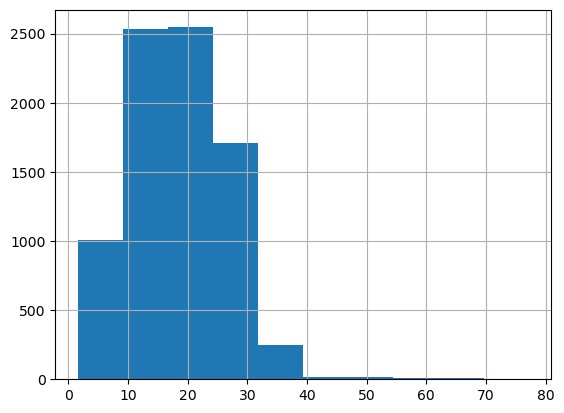

In [34]:
df["distance"].hist()

Model #1: distance as the only variable

In [35]:
# Feature and target
X1 = df[['distance']]
y1 = df['is_goal'].astype(int)

In [36]:
# Fit model
model1 = LogisticRegression()
model1.fit(X1, y1)

LogisticRegression()

In [37]:
df['xg_distance_only'] = model1.predict_proba(X1)[:, 1]

<Axes: >

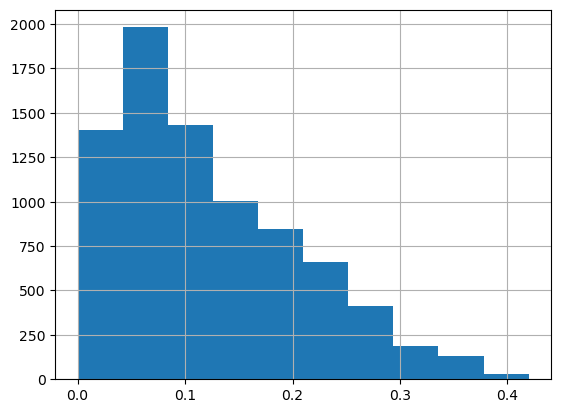

In [38]:
df['xg_distance_only'].hist()

In [39]:
print("Intercept:", model1.intercept_[0])
print("Distance coef:", model1.coef_[0][0])

Intercept: -0.14515073270917328
Distance coef: -0.11304513119944183


<Axes: xlabel='x', ylabel='y'>

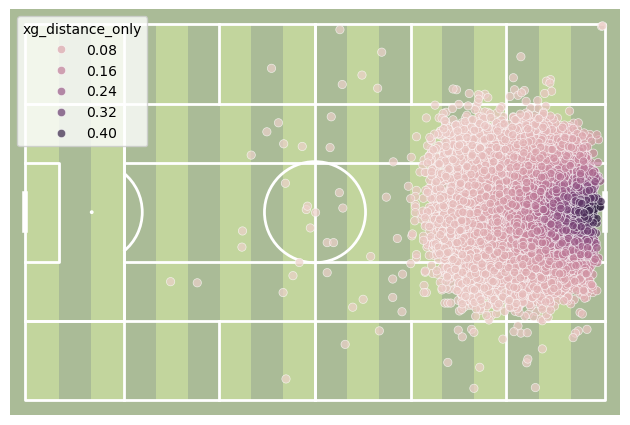

In [40]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=df, hue='xg_distance_only', alpha=0.7, ax=ax)

Model #2: distance + angle

In [41]:
left_post_y = 44
right_post_y = 56
goal_x = 100

# Distances to posts
df['dist_left_post'] = np.sqrt((goal_x - df['x'])**2 + (left_post_y - df['y'])**2)
df['dist_right_post'] = np.sqrt((goal_x - df['x'])**2 + (right_post_y - df['y'])**2)

# Goal width
goal_width = right_post_y - left_post_y

# Angle (radians)
df['angle'] = np.arccos(
    (df['dist_left_post']**2 + df['dist_right_post']**2 - goal_width**2) /
    (2 * df['dist_left_post'] * df['dist_right_post'])
)

<Axes: >

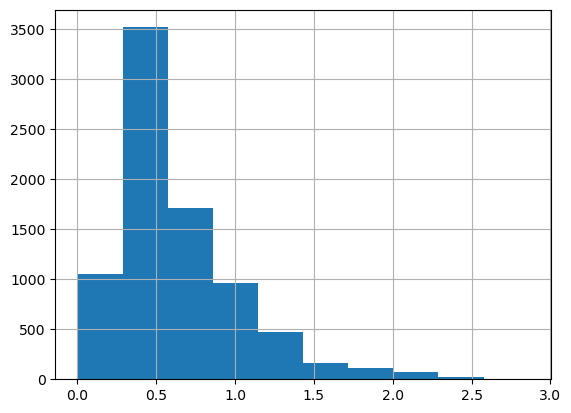

In [42]:
df["angle"].hist()

In [43]:
features = ['distance', 'angle']

X2 = df[features]
y2 = df['is_goal'].astype(int)

model2 = LogisticRegression()
model2.fit(X2, y2)

df['xg_distance_angle'] = model2.predict_proba(X2)[:, 1]

In [44]:
print("Intercept:", model2.intercept_[0])
print("Distance coef:", model2.coef_[0][0])
print("Angle coef:", model2.coef_[0][1])

Intercept: -2.1158590258095353
Distance coef: -0.04438057498154964
Angle coef: 1.1721977083538366


<Axes: xlabel='x', ylabel='y'>

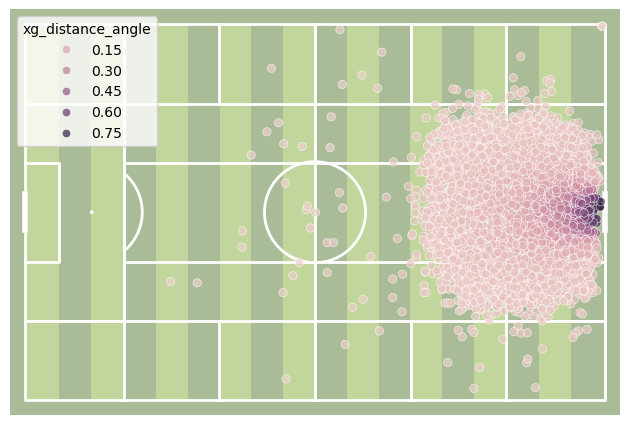

In [45]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=df, hue='xg_distance_angle', alpha=0.7, ax=ax)

Model #3. Distance and angle as variables but using CV.

In [46]:
features3 = ['distance', 'angle']

X3 = df[features3]
y3 = df['is_goal'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=0)

model3=LogisticRegression()
model3.fit(X_train, y_train)

y_pred_proba = model3.predict_proba(X_test)[:, 1]

In [47]:
print("Intercept:", model3.intercept_[0])
print("Distance coef:", model3.coef_[0][0])
print("Angle coef:", model3.coef_[0][1])

Intercept: -2.0764063859657456
Distance coef: -0.04436557739712295
Angle coef: 1.1330379672764233


In [48]:
final_df = X_test.copy()
final_df['xg'] = y_pred_proba

In [49]:
final_df

,distance,angle,xg
2048,28.369878,0.312494,0.048292
3491,14.203169,0.799291,0.141740
3744,11.500000,0.961775,0.182891
5862,23.576683,0.497031,0.071808
4198,8.004998,1.279340,0.272493
...,...,...,...
8,8.188406,1.261597,0.266931
7325,14.951254,0.498135,0.101989
4889,12.163059,0.880689,0.165457
4268,15.839192,0.558934,0.104722


In [45]:
logloss = log_loss(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
brier_score = brier_score_loss(y_test, y_pred_proba)

# Mostramos los resultados
print(f"Log Loss: {logloss:.4f}")  
print(f"ROC AUC: {roc_auc:.4f}")  
print(f"Brier Score: {brier_score:.4f}")

Log Loss: 0.3316
ROC AUC: 0.7454
Brier Score: 0.0972


Model #4: all types of variables as features inside the data set.

In [46]:
df = pd.get_dummies(df, columns=['period', 'Zone'])

In [47]:
X4 = df.drop('is_goal', axis=1)
y4 = df['is_goal'].astype(int)

model4 = LogisticRegression()
model4.fit(X4, y4)

df['xg_all_features'] = model4.predict_proba(X4)[:, 1]

In [48]:
print("Intercept:", model4.intercept_[0])
print("Distance coef:", model4.coef_[0][0])
print("Angle coef:", model4.coef_[0][1])

Intercept: -0.10675149299584329
Distance coef: -0.008890483095735086
Angle coef: -0.019907524124703663


<Axes: xlabel='x', ylabel='y'>

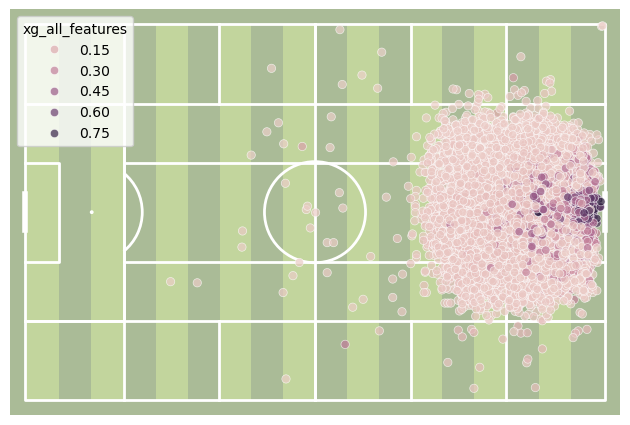

In [49]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=df, hue='xg_all_features', alpha=0.7, ax=ax)

# Scrape shot data for the first 18 rounds of the 2025/26 season for Fizz Liga

In [2]:
ss = sfc.Sofascore()

In [3]:
match_ids = [14019376, 14019373, 14019374, 14019371, 14019375, 14019440,
            14019378, 14019379, 14019380, 14019381, 14019382, 14019377,
            14019385, 14019388, 14019386, 14019387, 14019384, 14019383]

In [4]:
fizz = pd.DataFrame()

In [5]:
all_shots = []

for match_id in range(14019371, 14019483):  # end is exclusive
    try:
        shot = ss.scrape_match_shots(match_id)
        shot['match_id'] = match_id  # keep track of source match
        all_shots.append(shot)
    except Exception as e:
        print(f"Error with match {match_id}: {e}")

# Combine everything
shots = pd.concat(all_shots, ignore_index=True)

Running


In [6]:
fizz['x'] = shots['playerCoordinates'].apply(
    lambda coord: coord.get('x') if isinstance(coord, dict) else None
)

fizz['y'] = shots['playerCoordinates'].apply(
    lambda coord: coord.get('y') if isinstance(coord, dict) else None
)

In [7]:
fizz['goal'] = shots['goalType'].notna().astype(int)
fizz = fizz[shots['goalType'] != 'own']
shots['goalType'].value_counts(dropna=False)


goalType
NaN        2638
regular     284
penalty      35
own          13
Name: count, dtype: int64

In [8]:
fizz

,x,y,goal
0,11.5,50.0,1
1,12.8,53.9,0
2,33.0,30.3,0
3,21.0,59.3,0
4,12.2,49.3,0
...,...,...,...
2965,24.6,58.4,0
2966,11.1,49.7,0
2967,9.8,40.9,0
2968,15.0,30.9,0


<Axes: xlabel='x', ylabel='y'>

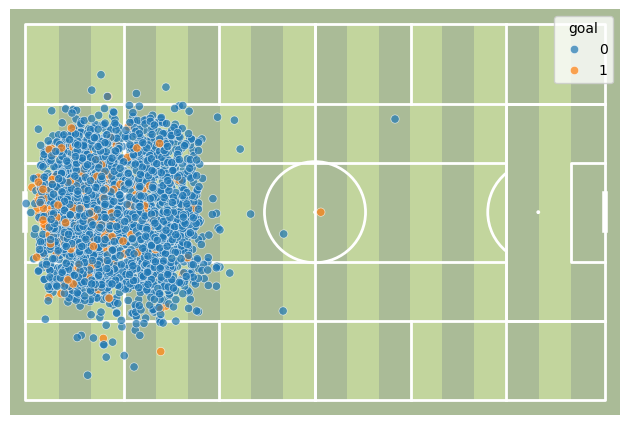

In [12]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=fizz, hue='goal', alpha=0.7, ax=ax)

In [18]:
# Flip coordinates
fizz['x'] = 100-fizz['x']
fizz['y'] = 100-fizz["y"]

<Axes: xlabel='x', ylabel='y'>

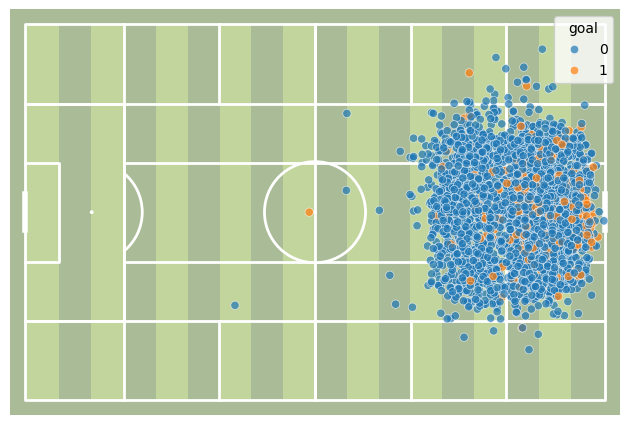

In [19]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=fizz, hue='goal', alpha=0.7, ax=ax)

In [20]:
goal_x, goal_y = 100, 50

fizz['distance'] = np.sqrt((goal_x - fizz['x'])**2 + (goal_y - fizz['y'])**2)

In [21]:
left_post_y = 44
right_post_y = 56

fizz['dist_left_post'] = np.sqrt((100 - fizz['x'])**2 + (left_post_y - fizz['y'])**2)
fizz['dist_right_post'] = np.sqrt((100 - fizz['x'])**2 + (right_post_y - fizz['y'])**2)

goal_width = right_post_y - left_post_y

fizz['angle'] = np.arccos(
    (fizz['dist_left_post']**2 + fizz['dist_right_post']**2 - goal_width**2) /
    (2 * fizz['dist_left_post'] * fizz['dist_right_post'])
)

In [50]:
fizz['xg'] = model3.predict_proba(fizz[['distance', 'angle']])[:, 1]

<Axes: xlabel='x', ylabel='y'>

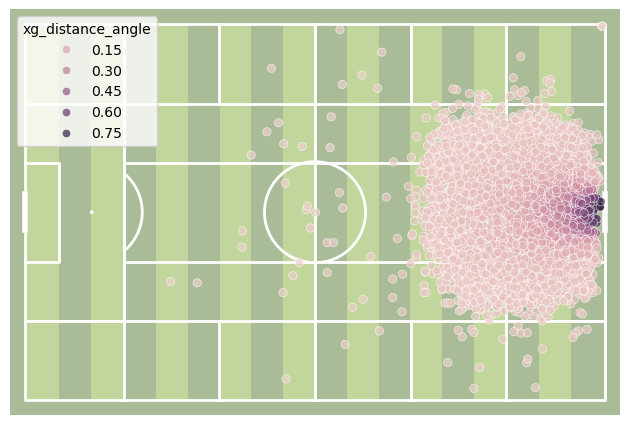

In [51]:
pitch = Pitch(pitch_type='opta', pitch_color='#aabb97', line_color='white',
              stripe_color='#c2d59d', stripe=True, positional=True, positional_color='white')

fig, ax = pitch.draw()

# Scatter plot
sns.scatterplot(x='x', y='y', data=df, hue='xg_distance_angle', alpha=0.7, ax=ax)

Calculate loss

In [73]:
y_pred = fizz['xg']
y_true = fizz['goal']

In [74]:
logloss = log_loss(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
brier_score = brier_score_loss(y_true, y_pred)

print(f"Log Loss: {logloss:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Brier Score: {brier_score:.4f}")

Log Loss: 0.3174
ROC AUC: 0.7078
Brier Score: 0.0912


Check xgfun.py

In [9]:
import xgfun as xg

In [10]:
ellenorzes = fizz.copy()

In [11]:
ellenorzes

,x,y,goal
0,11.5,50.0,1
1,12.8,53.9,0
2,33.0,30.3,0
3,21.0,59.3,0
4,12.2,49.3,0
...,...,...,...
2965,24.6,58.4,0
2966,11.1,49.7,0
2967,9.8,40.9,0
2968,15.0,30.9,0


In [12]:
ellenorzes = xg.calculate_xg_df(ellenorzes)

In [13]:
ellenorzes

,x,y,goal,xg
0,88.5,50.0,1,0.182891
1,87.2,46.1,0,0.149326
2,67.0,69.7,0,0.029955
3,79.0,40.7,0,0.071854
4,87.8,50.7,0,0.170063
...,...,...,...,...
2965,75.4,41.6,0,0.060664
2966,88.9,50.3,0,0.190522
2967,90.2,59.1,0,0.131319
2968,85.0,69.1,0,0.057443


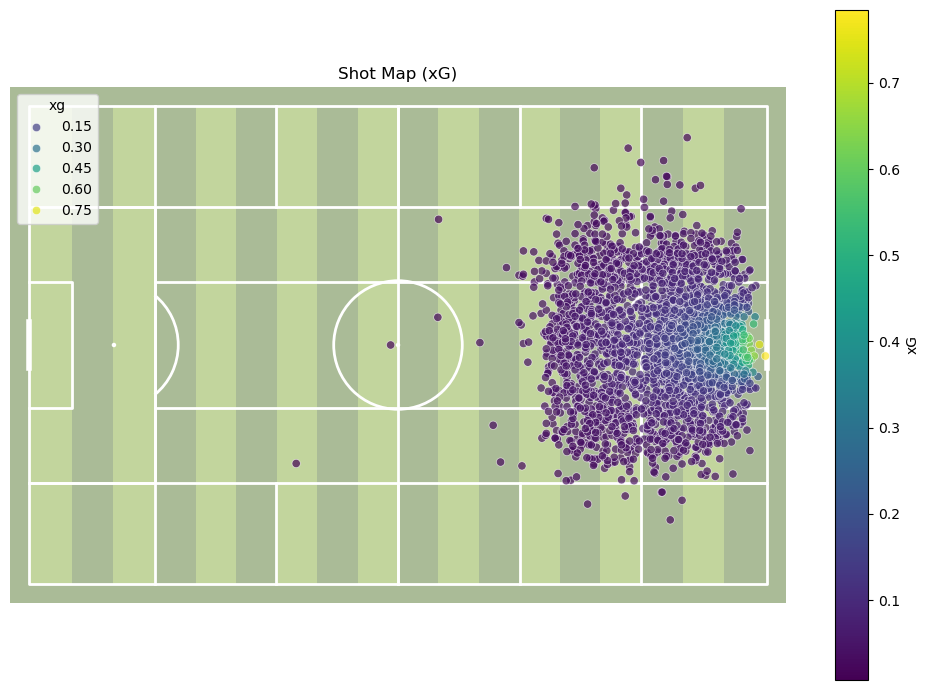

In [14]:
fig, ax = xg.plot_xg(ellenorzes)

In [15]:
(fizz['xg'] == ellenorzes['xg']).all()

KeyError: 'xg'

In [56]:
np.allclose(fizz['xg'], ellenorzes['xg'])

True

In [57]:
diff = fizz['xg'] - ellenorzes['xg']
diff.describe()

count    2.957000e+03
mean    -4.176947e-19
std      2.527030e-17
min     -2.220446e-16
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.220446e-16
Name: xg, dtype: float64